In [16]:
import pandas as pd 
read = pd.read_csv('Traffic.csv', encoding='latin1')
df = pd.DataFrame(read)
df = df.rename(columns={'Day of the week': 'Day_of_week'})
# print(read.info())
#HAMDLING DATA
# print(df.isnull().sum())
# print(df.dtypes)
# print(df.Time)
df["Time"] = pd.to_datetime(df["Time"], errors='coerce')
df["Date"] = pd.to_datetime(df["Date"], errors='coerce')

# print(df.dtypes)


In [ ]:

#ANALYZING DATA
#day by finding
day_analysis = df.groupby("Day_of_week")["Total"].agg(['max', 'min'])


# hour by finding 
df["Hour"] = df["Time"].dt.hour
hour = df.groupby("Hour")["Total"].mean().astype(int)

# TIme by finding
time_analysis = df.groupby("Hour")["Total"].agg(['max', 'min'])


#vehicle by finding 
print(df[["CarCount","BikeCount","BusCount","TruckCount","Total"]].corr().round(3)["Total"].sort_values(ascending=False))
#Now situalation wise 
Traffic_situ_day = df.groupby("Day_of_week")["Traffic Situation"].value_counts()
Traffic_situ_hour = df.groupby("Hour")["Traffic Situation"].value_counts()



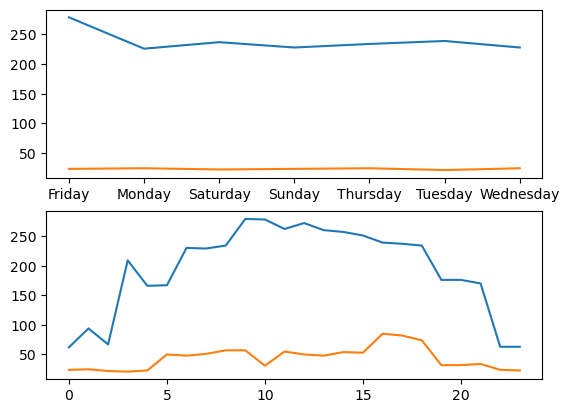

In [57]:
import matplotlib.pyplot as plt
#USING MATPLOTLIB
plt.subplot(2,1,1)
plt.plot(day_analysis)
plt.subplot(2,1,2)
plt.plot(time_analysis)
plt.show()

In [4]:
print(df.columns)

Index(['Time', 'Date', 'Day_of_week', 'CarCount', 'BikeCount', 'BusCount',
       'TruckCount', 'Total', 'Traffic Situation'],
      dtype='object')
